In [6]:
# =========================================
# IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [7]:
# =========================================
# COLUMN NAMES
# =========================================

column_names = [
    'SampleCode',
    'ClumpThickness',
    'UniformityCellSize',
    'UniformityCellShape',
    'MarginalAdhesion',
    'SingleEpithelialCellSize',
    'BareNuclei',
    'BlandChromatin',
    'NormalNucleoli',
    'Mitoses',
    'Class'
]

In [8]:
# =========================================
# LOAD DATASET
# =========================================

df = pd.read_csv(
    "BreastCancerWc.csv",
    names=column_names
)

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)


FIRST 5 ROWS
   SampleCode  ClumpThickness  UniformityCellSize  UniformityCellShape  \
0     1000025               5                   1                    1   
1     1002945               5                   4                    4   
2     1015425               3                   1                    1   
3     1016277               6                   8                    8   
4     1017023               4                   1                    1   

   MarginalAdhesion  SingleEpithelialCellSize BareNuclei  BlandChromatin  \
0                 1                         2          1               3   
1                 5                         7         10               3   
2                 1                         2          2               3   
3                 1                         3          4               3   
4                 3                         2          1               3   

   NormalNucleoli  Mitoses  Class  
0               1        1      2  
1            

In [9]:
# =========================================
# (i) DATA CLEANING
# =========================================

# Replace ? with NaN
df.replace("?", np.nan, inplace=True)

# Convert columns to numeric
for col in df.columns:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

# Check missing values
print("\nMISSING VALUES")
print(df.isnull().sum())

# Remove missing values
df_cleaned = df.dropna()

# Remove negative values
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns

df_cleaned = df_cleaned[
    (df_cleaned[numeric_cols] >= 0).all(axis=1)
]

print("\nSHAPE AFTER CLEANING")
print(df_cleaned.shape)


MISSING VALUES
SampleCode                   0
ClumpThickness               0
UniformityCellSize           0
UniformityCellShape          0
MarginalAdhesion             0
SingleEpithelialCellSize     0
BareNuclei                  16
BlandChromatin               0
NormalNucleoli               0
Mitoses                      0
Class                        0
dtype: int64

SHAPE AFTER CLEANING
(683, 11)


In [10]:
# =========================================
# (j) ERROR CORRECTING
# OUTLIER DETECTION & REMOVAL
# =========================================

def remove_outliers_iqr(df, columns):

    for col in columns:

        Q1 = df[col].quantile(0.25)

        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR

        upper = Q3 + 1.5 * IQR

        df = df[
            (df[col] >= lower) &
            (df[col] <= upper)
        ]

    return df

# Columns used for outlier removal
outlier_cols = [
    'ClumpThickness',
    'UniformityCellSize',
    'UniformityCellShape',
    'MarginalAdhesion'
]

df_no_outliers = remove_outliers_iqr(
    df_cleaned,
    outlier_cols
)

print("\nSHAPE AFTER OUTLIER REMOVAL")
print(df_no_outliers.shape)


SHAPE AFTER OUTLIER REMOVAL
(624, 11)


In [11]:
# =========================================
# (k) DATA TRANSFORMATION
# FEATURE SCALING
# =========================================

X = df_no_outliers.drop('Class', axis=1)

y = df_no_outliers['Class']

# Convert target values
# 2 -> 0 (Benign)
# 4 -> 1 (Malignant)

y = y.map({2:0, 4:1})

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Display transformed dataset
df_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("\nTRANSFORMED DATASET")
print(df_scaled.head())


TRANSFORMED DATASET
   SampleCode  ClumpThickness  UniformityCellSize  UniformityCellShape  \
0   -0.137152        0.289916           -0.630292            -0.678150   
1   -0.132580        0.289916            0.448233             0.434468   
2   -0.113036       -0.442503           -0.630292            -0.678150   
3   -0.111702        0.656125            1.886266             1.917957   
4   -0.110534       -0.076294           -0.630292            -0.678150   

   MarginalAdhesion  SingleEpithelialCellSize  BareNuclei  BlandChromatin  \
0         -0.598929                 -0.486252   -0.623356       -0.070734   
1          1.468743                  1.976584    2.063343       -0.070734   
2         -0.598929                 -0.486252   -0.324834       -0.070734   
3         -0.598929                  0.006315    0.272210       -0.070734   
4          0.434907                 -0.486252   -0.623356       -0.070734   

   NormalNucleoli   Mitoses  
0       -0.550932 -0.294574  
1       -0.

In [12]:
# ======================================.

# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================
# (l) LOGISTIC REGRESSION MODEL
# =========================================

logreg = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)

logreg_acc = accuracy_score(
    y_test,
    y_pred_logreg
)

# =========================================
# NAIVE BAYES MODEL
# =========================================

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_acc = accuracy_score(
    y_test,
    y_pred_nb
)


In [13]:
# =========================================
# ACCURACY COMPARISON
# =========================================

print("\n================================")
print("MODEL ACCURACY")
print("================================")

print("\nLogistic Regression Accuracy:")
print(logreg_acc)

print("\nNaive Bayes Accuracy:")
print(nb_acc)

# =========================================
# CLASSIFICATION REPORTS
# =========================================

print("\n================================")
print("LOGISTIC REGRESSION REPORT")
print("================================")

print(classification_report(
    y_test,
    y_pred_logreg
))

print("\n================================")
print("NAIVE BAYES REPORT")
print("================================")

print(classification_report(
    y_test,
    y_pred_nb
))


MODEL ACCURACY

Logistic Regression Accuracy:
0.944

Naive Bayes Accuracy:
0.944

LOGISTIC REGRESSION REPORT
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        89
           1       0.89      0.92      0.90        36

    accuracy                           0.94       125
   macro avg       0.93      0.94      0.93       125
weighted avg       0.94      0.94      0.94       125


NAIVE BAYES REPORT
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        89
           1       0.89      0.92      0.90        36

    accuracy                           0.94       125
   macro avg       0.93      0.94      0.93       125
weighted avg       0.94      0.94      0.94       125



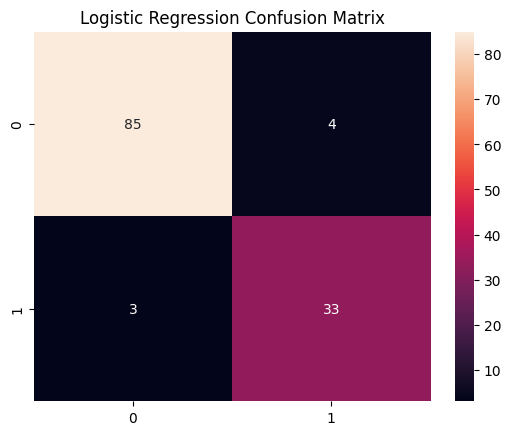

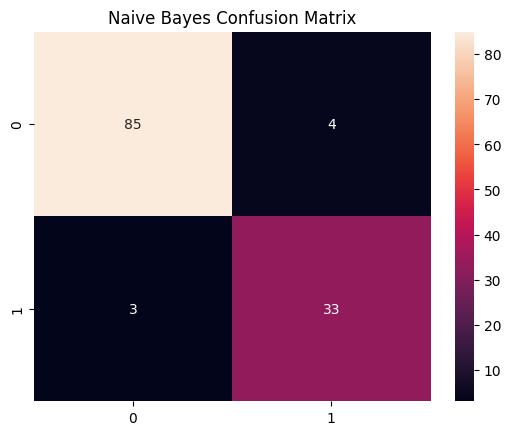


FINAL COMPARISON

Naive Bayes Performs Better


In [15]:
# =========================================
# CONFUSION MATRIX VISUALIZATION
# LOGISTIC REGRESSION
# =========================================

sns.heatmap(
    confusion_matrix(y_test, y_pred_logreg),
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

# =========================================
# CONFUSION MATRIX VISUALIZATION
# NAIVE BAYES
# =========================================

sns.heatmap(
    confusion_matrix(y_test, y_pred_nb),
    annot=True,
    fmt='d'
)

plt.title("Naive Bayes Confusion Matrix")

plt.show()

# =========================================
# FINAL COMPARISON
# =========================================

print("\n================================")
print("FINAL COMPARISON")
print("================================")

if logreg_acc > nb_acc:

    print("\nLogistic Regression Performs Better")

else:

    print("\nNaive Bayes Performs Better")